In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('최종_홍수취약성_랭킹.csv')

print("1. 반지하 주택(S1)과 하수도 인프라(S2, S3) 사이의 상관관계")
corr_s2, p_s2 = stats.pearsonr(df['S1_정규화'], df['S2_Vulnerability'])
corr_s3, p_s3 = stats.pearsonr(df['S1_정규화'], df['S3_Vulnerability'])

print(f"반지하(S1) vs 하수관거(S2) 상관계수: {corr_s2:+.4f} (P-value: {p_s2:.4f})")
print(f"반지하(S1) vs 빗물받이(S3) 상관계수: {corr_s3:+.4f} (P-value: {p_s3:.4f})")

1. 반지하 주택(S1)과 하수도 인프라(S2, S3) 사이의 상관관계
반지하(S1) vs 하수관거(S2) 상관계수: +0.1468 (P-value: 0.4839)
반지하(S1) vs 빗물받이(S3) 상관계수: -0.0991 (P-value: 0.6373)


두 인프라 모두 P-value가 0.05를 초과하여 유의미한 상관관계가 없다.
이는 취약 거주지(반지하)에 배수 인프라가 집중되지 않고 흩어져 있는 미스매치 상태를 보여준다.

In [10]:
print("2. 펌프장/저류조(AC)의 방어 효과 (독립표본 T-검정)")

# AC 지수 중앙값을 기준으로 두 그룹 분리
median_ac = df['AC_최종지수'].median()
high_ac_group = df[df['AC_최종지수'] >= median_ac]['V_최종지수']
low_ac_group  = df[df['AC_최종지수'] < median_ac]['V_최종지수']

# 두 집단 간 평균 차이 검정
t_stat_ac, p_val_ac = stats.ttest_ind(high_ac_group, low_ac_group)

print(f"펌프장/저류조 우수 그룹의 평균 홍수 취약성: {high_ac_group.mean():.4f}")
print(f"펌프장/저류조 미흡 그룹의 평균 홍수 취약성: {low_ac_group.mean():.4f}")
print(f"T-통계량: {t_stat_ac:.4f} (P-value: {p_val_ac:.4f})")

2. 펌프장/저류조(AC)의 방어 효과 (독립표본 T-검정)
펌프장/저류조 우수 그룹의 평균 홍수 취약성: 0.4278
펌프장/저류조 미흡 그룹의 평균 홍수 취약성: 0.6353
T-통계량: -2.6609 (P-value: 0.0140)


빗물 펌프장과 저류조 용량 확보는 피해를 막는 방어 효과를 가지고 있다.

In [11]:
print("3. 홍수 방재 정책의 핵심 타겟 도출 (OLS 다중회귀분석)")

# 독립변수(X)와 종속변수(Y) 설정
X = df[['표면유출_위험지수', 'S1_정규화', 'S2_Vulnerability', 'S3_Vulnerability', 'AC_최종지수']]
X = sm.add_constant(X) # 회귀식의 상수항(절편) 추가
Y = df['V_최종지수']

# statsmodels의 OLS(최소제곱법) 모델 적합
model = sm.OLS(Y, X).fit()

# 전체 통계표 출력 (R-squared, F-statistic, 변수별 P-value 등을 한눈에 확인)
print(model.summary())

3. 홍수 방재 정책의 핵심 타겟 도출 (OLS 다중회귀분석)
                            OLS Regression Results                            
Dep. Variable:                 V_최종지수   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                     441.6
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           5.79e-19
Time:                        16:12:44   Log-Likelihood:                 62.660
No. Observations:                  25   AIC:                            -113.3
Df Residuals:                      19   BIC:                            -106.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const

In [16]:
# 회귀분석 조건 만족 검증
print("다중공선성 (VIF) 검증")

vifs = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_df = pd.DataFrame({'변수명': X.columns, 'VIF': vifs})

print(vif_df[1:].to_string(index=False)) 

다중공선성 (VIF) 검증
             변수명      VIF
       표면유출_위험지수 1.074784
          S1_정규화 1.294501
S2_Vulnerability 1.927712
S3_Vulnerability 1.584558
         AC_최종지수 1.615067


모든 VIF가 10 미만이므로 다중공선성 문제 없음.

In [17]:
print("잔차의 정규성 및 등분산성 검증")
residuals = model.resid

# 정규성 검정 (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

# 등분산성 검정 (Breusch-Pagan)
bp_test = sms.het_breuschpagan(residuals, model.model.exog)
bp_p = bp_test[1]

print(f"정규성 (Shapiro-Wilk): P-value = {shapiro_p:.4f}")
print(f"등분산성 (Breusch-Pagan): P-value = {bp_p:.4f}")


잔차의 정규성 및 등분산성 검증
정규성 (Shapiro-Wilk): P-value = 0.6895
등분산성 (Breusch-Pagan): P-value = 0.7375


정규성과 등분산성 검증 모두 P-value가 0.05보다 크므로 귀무가설을 채택한다. 즉, 오차가 정규성과 등분산성을 가지고 있다.

In [19]:
print("이상치 탐지")
influence = model.get_influence()
cooks_d, _ = influence.cooks_distance

# 임계값 설정 (4 / 데이터 개수)
n = len(Y)
threshold = 4 / n
print(f"Cook's Distance 임계값: {threshold:.4f}")

# 이상치 추출
outlier_indices = np.where(cooks_d > threshold)[0]
outliers = df.loc[outlier_indices, ['자치구']]

if len(outliers) > 0:
    print(f"회귀선에 큰 영향을 미치는 이상치 의심 자치구: {len(outliers)}곳")
    print(outliers.to_string(index=False))
else:
    print("임계값을 초과하는 이상치 없음")

이상치 탐지
Cook's Distance 임계값: 0.1600
회귀선에 큰 영향을 미치는 이상치 의심 자치구: 4곳
 자치구
 구로구
동대문구
 서초구
 성북구


[결론 및 시사점 요약]
1. 모델의 설명력(R-squared)이 99.1%로 매우 강력한 예측력을 가진다.
2. 표면유출 위험지수(Coefficient: 0.5883)가 취약성을 높이는 가장 큰 요인이다.
3. 방어 인프라 중 하수관거(S2)나 빗물받이(S3)보다, 펌프장/저류조(AC, Coefficient: -0.8989)의 취약성 감소 효과가 압도적으로 뛰어남이 입증되었다.
4. 결론적으로 향후 방재 예산은 '표면유출 억제' 및 '저류/펌프 시설 확충'에 집중되어야 한다.

++ 모델은 VIF, 정규성 모두 만족하지만, Cook's distance 기준 4개 지역(구로, 동대문, 서초, 성북)이 이상치로 탐지되었다.

[이상치 포함 근거]
1. 현실 특수성 반영
- 서초구(분지형 지형) 등 해당 지역의 실제 지리직 특수성을 보여줄 수 있음.
- 즉, 인위적으로 제거 시 현실을 왜곡할 가능성 존재
2. 정책적 사각지대
- 일반적인 펌프/하수도 확충만으로는 수해를 막을 수 없는 곳을 의미
- 즉, 이상치에 해당하는 자치구는 맞춤형 특수 방재 정책이 필요하다는 증거
3. 객관성 입증
- 극단값을 삭제하지 않았음에도 모델의 설명력이 매우 높게 나타남


In [21]:
# [한글 폰트 설정]
plt.rc('font', family='Malgun Gothic') 
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

In [23]:
# 1. 모델 재적합
X_vars = ['표면유출_위험지수', 'S1_정규화', 'S2_Vulnerability', 'S3_Vulnerability', 'AC_최종지수']
X = sm.add_constant(df[X_vars])
Y = df['V_최종지수']

model = sm.OLS(Y, X).fit()

In [24]:
# 2. 잔차(Residual) 
df['예측_취약성'] = model.predict(X)
df['잔차'] = df['V_최종지수'] - df['예측_취약성']

In [ ]:
# 3. 이상치 4개 구 필터링
outlier_names = ['구로구', '동대문구', '서초구', '성북구']
outliers_df = df[df['자치구'].isin(outlier_names)].copy()

In [26]:
print("4개 이상치 지역의 잔차(예측 오차) 방향성 분석")
for idx, row in outliers_df.iterrows():
    name = row['자치구']
    actual = row['V_최종지수']
    pred = row['예측_취약성']
    res = row['잔차']
    
    direction = "과소 예측(실제 취약성이 더 높음)" if res > 0 else "과대 예측(실제 취약성이 더 낮음)"
    
    print(f"{name}: 실제({actual:.3f}) vs 예측({pred:.3f}) | 오차: {res:+.3f} -> {direction}")

4개 이상치 지역의 잔차(예측 오차) 방향성 분석
구로구: 실제(0.868) vs 예측(0.825) | 오차: +0.043 -> 과소 예측(실제 취약성이 더 높음)
동대문구: 실제(0.569) vs 예측(0.603) | 오차: -0.034 -> 과대 예측(실제 취약성이 더 낮음)
서초구: 실제(0.211) vs 예측(0.172) | 오차: +0.039 -> 과소 예측(실제 취약성이 더 높음)
성북구: 실제(0.000) vs 예측(-0.021) | 오차: +0.021 -> 과소 예측(실제 취약성이 더 높음)


- 양수(+) 잔차: 모델이 인프라만 보고 안전할 것이라 예측했으나, 실제론 훨씬 취약함. (지형적 악조건 의심)
- 음수(-) 잔차: 모델이 '위험할 것'이라 예측했으나, 실제론 방어를 잘함. (통계에 안 잡히는 특수 방어기제 의심)

서울시 평균 vs 이상치 4개 구 극단치 프로파일링 (시각화)


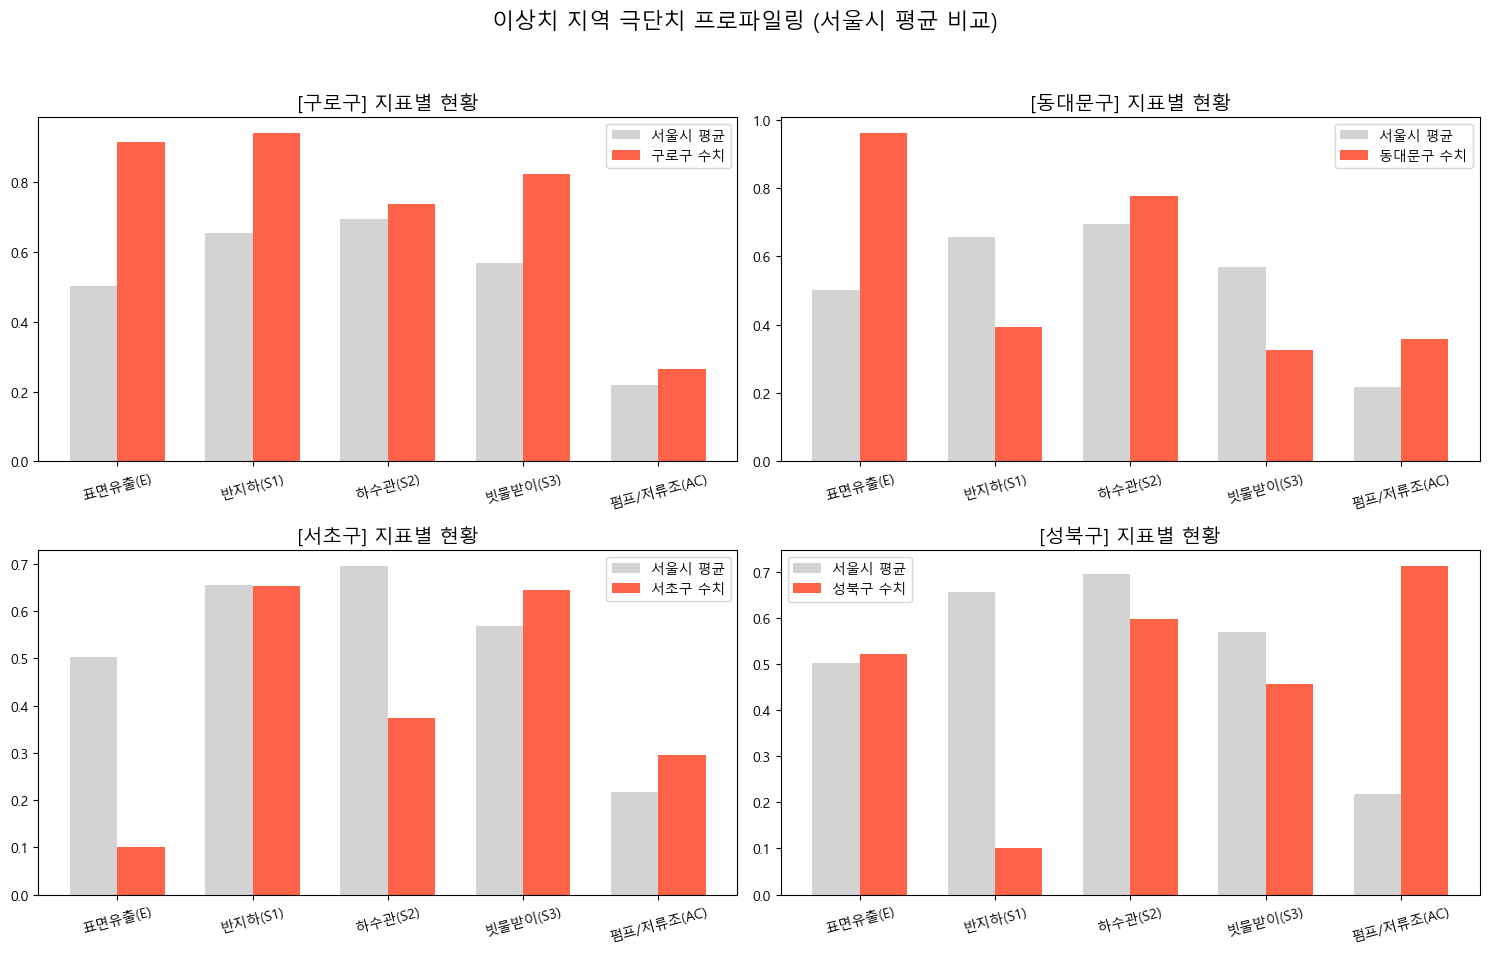

In [27]:
print("서울시 평균 vs 이상치 4개 구 극단치 프로파일링 (시각화)")
# 서울시 전체 평균 계산
seoul_mean = df[X_vars].mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('이상치 지역 극단치 프로파일링 (서울시 평균 비교)', fontsize=16)

axes = axes.flatten()

for i, name in enumerate(outlier_names):
    ax = axes[i]
    district_data = df[df['자치구'] == name][X_vars].iloc[0]
    
    x = np.arange(len(X_vars))
    width = 0.35
    
    ax.bar(x - width/2, seoul_mean, width, label='서울시 평균', color='lightgray')
    ax.bar(x + width/2, district_data, width, label=f'{name} 수치', color='tomato')
    
    ax.set_title(f'[{name}] 지표별 현황', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(['표면유출(E)', '반지하(S1)', '하수관(S2)', '빗물받이(S3)', '펌프/저류조(AC)'], rotation=15)
    ax.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

- E, S1, S2, S3는 1에 가까울수록 취약함을 나타냄.
- AC는 낮을수록 취약함을 나타냄.

### 1.서초구 : 인프라를 무력화시키는 지형
- 데이터 분석
    - 모델 예측치(0.172)보다 실제 취약성(0.211)이 더 높은 과소 예측(+) 지역.
    - 표면유출 위험(E=0.100)과 하수관거 취약성(S2=0.374)이 낮아 통계 모델은 안전하다고 판단
    - 그러나 핵심 방어막인 AC 지수가 0.296으로 하위권에 머물러 있음

- 스토리텔링
    - 비가 땅에 덜 고이고(낮은 E), 하수관 상태가 나쁘지 않음(낮은 S2)에도 실제 침수 피해가 컸음
    - 이는 강남역 일대의 '항아리형 저지대'라는 공간적 특수성 때문
    - 다른 곳에서 흘러들어온 물이 순식간에 집중되지만, 이를 감당할 저류 용량(2,203㎥)과 펌프 시설이 유입량을 버텨내지 못해 통계적 예측치를 깨고 침수가 발생

- 정책 제언
    - 서초구에는 단순히 하수관을 넓히는 선형적 방재가 통하지 않음
    - 저지대로 쏟아지는 물을 강제로 모아 배출할 수 있는 대심도 빗물 배수터널 수준의 거대한 입체적 인프라 신설이 필요
    - 대심도 빗물 배수터널 : 도시의 극심한 침수 피해를 막기위해 지하 40-50M 깊이에 건설되는 거대한 지하 저류 터널

### 2. 구로구 : 높은 반지하 비율과 낮은 저류 용량
- 데이터 분석
    - 모델 예측치(0.825)보다 실제 취약성(0.868)이 더 높은 과소 예측(+) 지역
    - 반지하 밀집도에 따른 물리적 취약성(S1)이 0.941로 서울시 최고 수준에 달하며, 하수도/빗물받이 취약성(S2, S3) 역시 매우 높음 
    - 반면 방어를 담당할 AC 지수는 0.264에 불과함

- 스토리텔링
    - 침수에 가장 치명적인 반지하 주택이 빽빽하게 밀집해 있음에도 불구하고, 구로구의 빗물 저류 용량은 '0㎥'로 나타남
    - 도림천 등 하천 인접성까지 고려하면, 한 번 물이 넘치면 이를 가둬둘 곳이 없는 상태

- 정책 제언
    - 반지하 밀집 구역 주변으로 초소형/중소형 저류조 시설을 신설 
       -> 여기서 행정동별 반지하 분석 한 것 쓰면 될듯함
    - 기존 10개의 펌프장 용량을 대대적으로 증설하는 데 예산 투자

### 3. 성북구 : 높은 저류 용량이 만들어낸 안전지대
- 데이터 분석
    - 실제 취약성 0.000(가장 안전함), 모델 예측치마저 -0.021로 한계선을 뚫고 내려간 지역
    - 하수관(S2)과 빗물받이(S3) 취약성이 중간 수준(0.4~0.5) 존재함에도, 방어력인 AC 지수가 0.711로 1위

- 스토리텔링
    - 다중회귀분석에서 증명된 "AC(펌프장/저류조)가 가장 강력한 방어 인프라"라는 가설을 현실에서 완벽하게 증명하는 지역
    - 펌프장 개수는 2개뿐이지만, 저류 용량이 무려 12,194㎥에 달함
    - 하수관망이 다소 취약해도, 거대한 저류조로 인해 완벽한 방어력을 보여줌.

- 정책 제언
    - 홍수 방어 인프라 배치의 모범 자치구
    - 대규모 저류 시설의 효과가 입증된 만큼, 현재 시설의 주기적인 준설 및 유지보수에만 집중해도 수해 방어에 효과적

### 4. 동대문구 : 15개의 펌프장 네트워크
- 데이터 분석
    - 모델 예측치(0.603)보다 실제 취약성(0.569)이 낮은 과대 예측(-) 지역
    - 통계적으로 하수관 취약성(S2)이 0.778로 매우 위험하고, 저류 용량 역시 단 4㎥에 불과해 모델은 동대문구를 위험한 곳으로 평가함

- 스토리텔링
    - 저류조가 사실상 없고 하수관이 낡아 취약함에도 15개의 펌프장이 촘촘하게 배치(서울시 최상위권)
    - 물을 모아두지 못하는 대신 펌프를 풀가동하여 실시간으로 물을 퍼내는 방식으로 악조건을 상쇄하고 있는 독특한 방어 체계

- 정책 제언
    - 당장은 15개의 펌프로 잘 버티고 있지만, 펌프가 고장 나거나 극한 폭우로 일일 처리 용량을 초과하면 치명적인 하수관 취약성(S2=0.778)이 폭발할 수 있음
    - 펌프에만 의존하는 구조를 탈피하기 위해 노후 하수관거(S2) 개량 사업이 최우선으로 배정되어야 함